# PLOT STACKED SPECTRA

In [1]:
from spectraPyle.plot.plot import plotting, plot_h5_heatmap

In [2]:
#name_stack = "/media/home/my_workspace/Euclid_Q1/Paper/data/DESI/catalogue_SF_matched_Q1__ON_idCol_desi_euclid_id_zCol_ext_z__zType_restfr_z__galExtCol_null__conservation_none__norm_median__pxlResamp_1__sigmaClip_2__bootstrapping_350__bitMask0__NdithMask2_STACKING.fits"
#name_stack = "/media/user/Euclid_Q1/Paper/data/DESI/templates_Q1/results_v_14_10_2025/SFG_DESI_TEMPLATES_SF_1.5z1.75__ON_idCol_desi_Euclid_ID_zCol_z_spec__zType_restfr_z__galExtCol_null__conservation_none__norm_interval_1440.0_lbdRest_3572.36__pxlResamp_1__sigmaClip_2__bootstrapping_350__bitMask0__NdithMask2_STACKING.fits"

#name_stack = "~/Documents/coding/PYTHON/SpectraPyle_project/SpectraPyle/project_root/tests/INDIVIDUAL_FITS/outputs/catalog_list__idCol_object_id__zCol_spe_z__zType_rest_frame__galExtCol_None__conservation_None__spectraNormalization_template__sigmaClip_3.0__bootstrapping_300____NdithMask3__STACKING.fits"
name_stack = "/Users/salvatorequai/Documents/EUCLID/DR1/spettri_test/output/test_vis_insp_no_duplicates__idCol_object_id__zCol_spe_z__zType_rest_frame__galExtCol_None__conservation_None__spectraNormalization_median__sigmaClip_3.0__bootstrapping_300____NdithMask3__STACKING.fits"

Plotting /Users/salvatorequai/Documents/EUCLID/DR1/spettri_test/output/test_vis_insp_no_duplicates__idCol_object_id__zCol_spe_z__zType_rest_frame__galExtCol_None__conservation_None__spectraNormalization_median__sigmaClip_3.0__bootstrapping_300____NdithMask3__STACKING.fits stack results


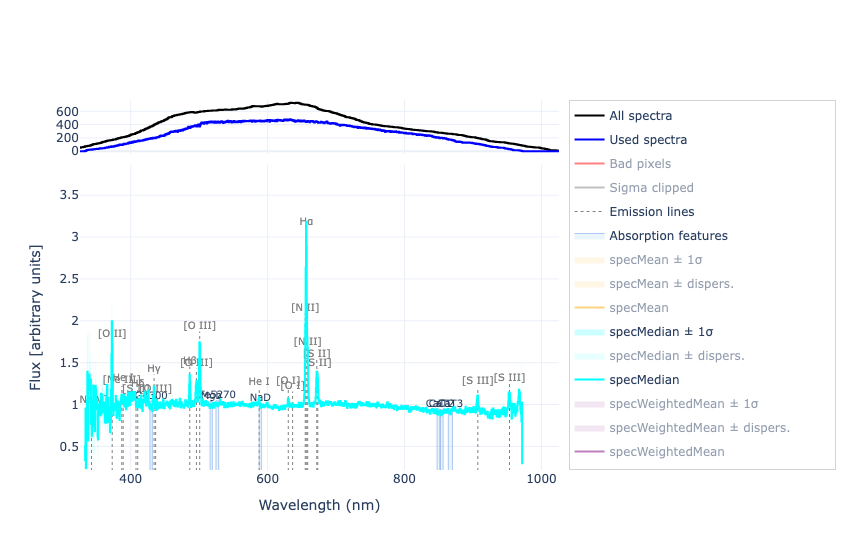

In [3]:
plotting(name_stack, width=850, height=550)

**Having trouble seeing the plot? A quick browser refresh should do the trick!**

---
## 2D HEATMAP / THIN LINES — H5 array viewer

In [4]:
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
_fits_p   = Path(name_stack).expanduser()
fits_path = str(_fits_p)
h5_path   = str(_fits_p.parent / (_fits_p.stem + '_array.h5'))

print(f"FITS : {fits_path}")
print(f"H5   : {h5_path}")

# ── Available metrics from the FITS ────────────────────────────────────────
from astropy.io import fits as astrofits
with astrofits.open(fits_path) as hdul:
    all_cols = list(hdul['STACKING_RESULTS'].columns.names)
    wavelength_col = hdul['STACKING_RESULTS'].data['wavelength']
    n_pixels = len(wavelength_col)

metric_choices = [c for c in all_cols
                  if c.startswith('spec')
                  and not any(s in c for s in ('Error','Dispersion','16th','84th','98th','99th'))]

# ── Widgets ────────────────────────────────────────────────────────────────
w_mode     = widgets.ToggleButtons(options=['heatmap','lines'],  description='Mode',    value='heatmap')
w_template = widgets.ToggleButtons(options=['original','norm'],  description='Array',   value='original')
w_metric   = widgets.Dropdown(     options=metric_choices,       description='Metric',  value='specMedian')
w_normfact = widgets.Checkbox(     value=False,                  description='Norm factors')
w_maxspec  = widgets.BoundedIntText(value=0, min=0, max=100000, step=100,
                                    description='Max spectra (0=all, random)')
w_alpha    = widgets.FloatSlider(  value=0.05, min=0.01, max=0.5, step=0.01,
                                   description='Line alpha',
                                   layout=widgets.Layout(width='400px'))
w_binsx    = widgets.IntSlider(    value=n_pixels, min=10, max=n_pixels, step=10,
                                   description=f'X bins (max={n_pixels})',
                                   layout=widgets.Layout(width='400px'))
w_binsy    = widgets.IntSlider(    value=200, min=10, max=500, step=10,
                                   description='Y bins',
                                   layout=widgets.Layout(width='400px'))
w_button   = widgets.Button(description='Plot', button_style='primary',
                             layout=widgets.Layout(width='120px'))
out = widgets.Output()

def on_plot(_):
    out.clear_output(wait=True)
    with out:
        max_s = w_maxspec.value if w_maxspec.value > 0 else None
        fig = plot_h5_heatmap(
            h5_path        = h5_path,
            fits_path      = fits_path,
            template_array = w_template.value,
            metric         = w_metric.value,
            norm_factors   = w_normfact.value,
            mode           = w_mode.value,
            max_spectra    = max_s,
            line_alpha     = w_alpha.value,
            nbinsx         = w_binsx.value,
            nbinsy         = w_binsy.value,
        )
        display(fig)

w_button.on_click(on_plot)

display(widgets.VBox([
    widgets.HBox([w_mode, w_template]),
    widgets.HBox([w_metric, w_normfact]),
    widgets.HBox([w_maxspec, w_alpha]),
    widgets.HBox([w_binsx, w_binsy]),
    w_button,
    out,
]))

FITS : /Users/salvatorequai/Documents/EUCLID/DR1/spettri_test/output/test_vis_insp_no_duplicates__idCol_object_id__zCol_spe_z__zType_rest_frame__galExtCol_None__conservation_None__spectraNormalization_median__sigmaClip_3.0__bootstrapping_300____NdithMask3__STACKING.fits
H5   : /Users/salvatorequai/Documents/EUCLID/DR1/spettri_test/output/test_vis_insp_no_duplicates__idCol_object_id__zCol_spe_z__zType_rest_frame__galExtCol_None__conservation_None__spectraNormalization_median__sigmaClip_3.0__bootstrapping_300____NdithMask3__STACKING_array.h5
